# Random Tree Diabetes

## - Carga y filtrado de datos (sin Insulin ni SkinThickness)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. División y Optimización
from sklearn.model_selection import train_test_split, GridSearchCV

# 3. Modelos (Los dos que vas a comparar)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 4. Métricas de evaluación
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [8]:
df = pd.read_csv('/workspaces/IgnacioSabinoG-IntroML/data/raw/diabetes.csv')

df.drop(['Insulin', 'SkinThickness'], axis=1, inplace=True)

indices_a_eliminar = df[(df['Glucose'] == 0) | (df['BMI'] == 0) | (df['BloodPressure'] == 0)].index
df.drop(indices_a_eliminar, inplace=True)
df = df.reset_index(drop=True)
df

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,33.6,0.627,50,1
1,1,85,66,26.6,0.351,31,0
2,8,183,64,23.3,0.672,32,1
3,1,89,66,28.1,0.167,21,0
4,0,137,40,43.1,2.288,33,1
...,...,...,...,...,...,...,...
719,10,101,76,32.9,0.171,63,0
720,2,122,70,36.8,0.340,27,0
721,5,121,72,26.2,0.245,30,0
722,1,126,60,30.1,0.349,47,1


In [9]:
x = df.drop('Outcome', axis=1)
y = df['Outcome']

In [10]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

In [11]:
# 1. Definimos el espacio de búsqueda para Random Forest
# Añadimos 'n_estimators' que es el número de árboles
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [4, 6, 8, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', 'balanced_subsample', None],
    'random_state': [42]
}

# 2. Configuramos el Grid Search
grid_search_rf = GridSearchCV(
    RandomForestClassifier(), 
    param_grid_rf, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1 # Usa todos los núcleos de tu procesador para ir más rápido
)

# 3. Entrenamos
grid_search_rf.fit(x_train, y_train)

# 4. Obtenemos el mejor modelo y evaluamos
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(x_test)

print(f"Mejores parámetros RF: {grid_search_rf.best_params_}")
print(f"Precisión RF: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nInforme de Clasificación Random Forest:")
print(classification_report(y_test, y_pred_rf))

Mejores parámetros RF: {'class_weight': None, 'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 50, 'random_state': 42}
Precisión RF: 0.7862

Informe de Clasificación Random Forest:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       102
           1       0.65      0.60      0.63        43

    accuracy                           0.79       145
   macro avg       0.74      0.73      0.74       145
weighted avg       0.78      0.79      0.78       145



<Axes: title={'center': 'Importancia de las Variables (RF)'}>

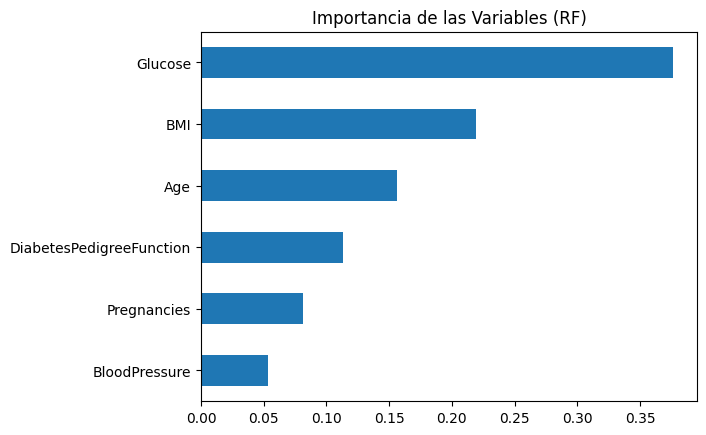

In [12]:
importances = pd.Series(best_rf.feature_importances_, index=x.columns)
importances.sort_values().plot(kind='barh', title='Importancia de las Variables (RF)')

El Decision Tree dio mejor resultado (0.83 vs 0.79) que el Random Forest, aunque suele ser mejor en general.

Quizá el balanceo de clase en el Decision Tree es la clave para subir el recall de la clase 1 (diabéticos) a 0.72. En cambio, en el Random Forest, el GridSearch eligió class_weight: None, lo que hace que el modelo se enfoque más en los sanos y baja la efectividad con los diabéticos (0.60).

Tamaño del dataset: Con unos 145 datos de test (unos 700 en total), el dataset es pequeño. A veces, un solo árbol bien podado (max_depth=4) es más que suficiente y un Random Forest puede añadir ruido innecesario.

Se intentará a continuación forzar a ser balanced, probar con n_estimators: [100, 200, 300] en el GridSearch ya que con 50 árboles quizás se quedó corto y, por último, ajustar la profundidad, ya que si el árbol simple funcionó bien con max_depth=4, se probará en el RF un rango más bajo como [3, 4, 5].

In [16]:
from sklearn.ensemble import RandomForestClassifier

# 1. Definimos el espacio de búsqueda forzando 'balanced'
param_grid_rf = {
    'n_estimators': [100, 200, 300],          # Más árboles para dar estabilidad
    'max_depth': [3, 4, 5, 6],                # Profundidades similares a tu árbol de decisión
    'min_samples_split': [5, 10, 20],
    'class_weight': ['balanced'],             # <--- Forzamos el balanceo aquí
    'random_state': [42]
}

# 2. Grid Search
grid_search_rf = GridSearchCV(
    RandomForestClassifier(), 
    param_grid_rf, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1
)

# 3. Entrenamiento
grid_search_rf.fit(x_train, y_train)

# 4. Evaluación
best_rf_balanced = grid_search_rf.best_estimator_
y_pred_rf = best_rf_balanced.predict(x_test)

print(f"Mejores parámetros RF (Forzado Balanced): {grid_search_rf.best_params_}")
print(f"Nueva Precisión RF: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nNuevo Informe de Clasificación Random Forest:")
print(classification_report(y_test, y_pred_rf))

Mejores parámetros RF (Forzado Balanced): {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200, 'random_state': 42}
Nueva Precisión RF: 0.7724

Nuevo Informe de Clasificación Random Forest:
              precision    recall  f1-score   support

           0       0.90      0.76      0.83       102
           1       0.59      0.79      0.67        43

    accuracy                           0.77       145
   macro avg       0.74      0.78      0.75       145
weighted avg       0.80      0.77      0.78       145



El Random Forest Balanced (0.77) se volvió un "detector agresivo". Tiene el Recall más alto (0.79) de todas tus pruebas. Esto significa que detecta a casi todos los diabéticos, pero a cambio de cometer más errores con los sanos (su precisión en la clase 1 bajó a 0.59).